In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
import pandas as pd

df = pd.read_csv("../data/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
X = df[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
]

y = df["Machine failure"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9835


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.82      0.59      0.69        61

    accuracy                           0.98      2000
   macro avg       0.90      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [13]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1931    8]
 [  25   36]]


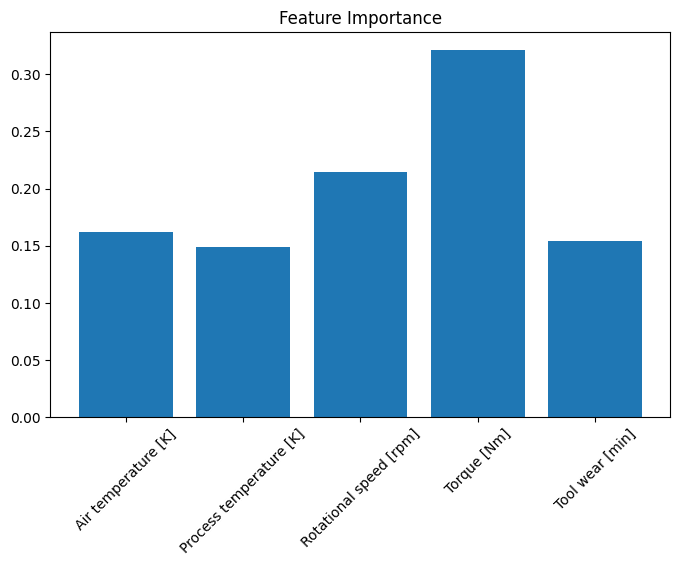

In [14]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [15]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
pip show shap

Name: shap
Version: 0.51.0
Summary: A unified approach to explain the output of any machine learning model.
Home-page: 
Author: 
Author-email: Scott Lundberg <slund1@cs.washington.edu>
License: MIT License
Location: C:\Users\sanja\AppData\Roaming\Python\Python313\site-packages
Requires: cloudpickle, llvmlite, numba, numpy, packaging, pandas, scikit-learn, scipy, slicer, tqdm, typing-extensions
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [17]:
import shap

In [18]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

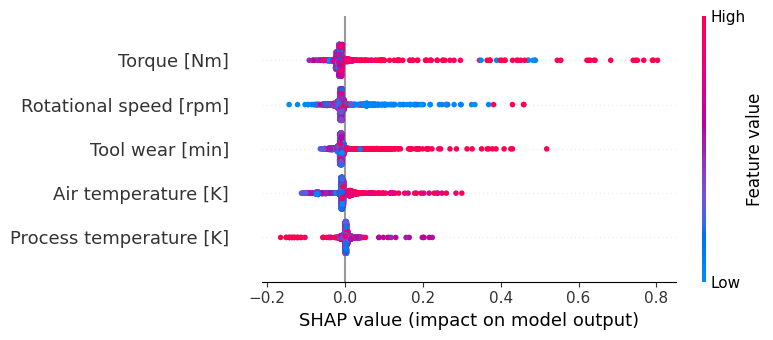

In [19]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test
)

In [20]:
X_test.iloc[[0]]

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
6252,300.8,310.3,1538,36.1,198


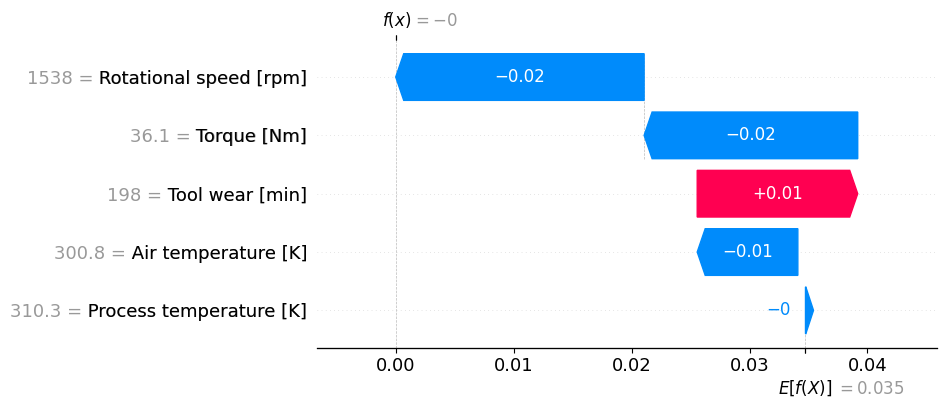

In [21]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0,:,1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [22]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import joblib

joblib.dump(
    model,
    "../models/predictive_model.pkl"
)

print("Model Saved")

Model Saved


In [28]:
import joblib

# Load the model you already saved
loaded_model = joblib.load("../models/predictive_model.pkl")

# Test it on one sample
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample).ravel()[0]

print("Prediction:", "Failure" if prediction == 1 else "Normal")

# Display probabilities, if supported
if hasattr(loaded_model, "predict_proba"):
    probability = loaded_model.predict_proba(sample)[0]
    print("Class probabilities:", probability)

Prediction: Normal
Class probabilities: [1. 0.]


In [29]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [30]:
%pip install catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 1.1 MB/s eta 0:01:28
    --------------------------------------- 1.3/100.2 MB 1.3 MB/s eta 0:01:14
    --------------------------------------- 1.6/100.2 MB 1.4 MB/s eta 0:01:11
    --------------------------------------- 1.8/100.2 MB 1.3 MB/s eta 0:01:17
    --------------------------------------- 2.1/100.2 MB 1.2 MB/s eta 0:01:21
   - -------------------------------------- 2.6/100.2 MB 1.3 MB/s eta 0:01:16
   - -------------------------------------- 2.9/100.2 MB 1.3 MB/s eta 0:01:15
   - -------------------------------------- 3.1/100.2 MB 1.3 MB/s eta 0:01:15
   - -------------------------------------- 3.1/100.2 MB 1.3 MB/s eta 0:01:15
   - --


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Identify categorical features
categorical_features = (
    ["Type"] if "Type" in X_train.columns else []
)

# Create a separate CatBoost model
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

# Train the model
cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

# Generate predictions
cat_pred = cat_model.predict(X_test).ravel()

# Evaluate performance
print("CatBoost Accuracy:",
      accuracy_score(y_test, cat_pred))

print("\nClassification Report:")
print(classification_report(y_test, cat_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, cat_pred))

0:	learn: 0.9652500	total: 124ms	remaining: 1m 1s
100:	learn: 0.9863750	total: 1.51s	remaining: 5.99s
200:	learn: 0.9918750	total: 2.66s	remaining: 3.96s
300:	learn: 0.9936250	total: 3.58s	remaining: 2.37s
400:	learn: 0.9956250	total: 4.69s	remaining: 1.16s
499:	learn: 0.9962500	total: 5.84s	remaining: 0us
CatBoost Accuracy: 0.9855

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.88      0.61      0.72        61

    accuracy                           0.99      2000
   macro avg       0.93      0.80      0.86      2000
weighted avg       0.98      0.99      0.98      2000


Confusion Matrix:
[[1934    5]
 [  24   37]]


In [32]:
from sklearn.metrics import accuracy_score

rf_pred = model.predict(X_test).ravel()

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("CatBoost Accuracy:",
      accuracy_score(y_test, cat_pred))

Random Forest Accuracy: 0.9835
CatBoost Accuracy: 0.9855


In [33]:
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

cat_model.save_model(
    str(model_dir / "predictive_maintenance_catboost.cbm")
)

print("CatBoost model saved successfully!")

CatBoost model saved successfully!


CatBoost Accuracy: 0.9855

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1939
     Failure       0.88      0.61      0.72        61

    accuracy                           0.99      2000
   macro avg       0.93      0.80      0.86      2000
weighted avg       0.98      0.99      0.98      2000



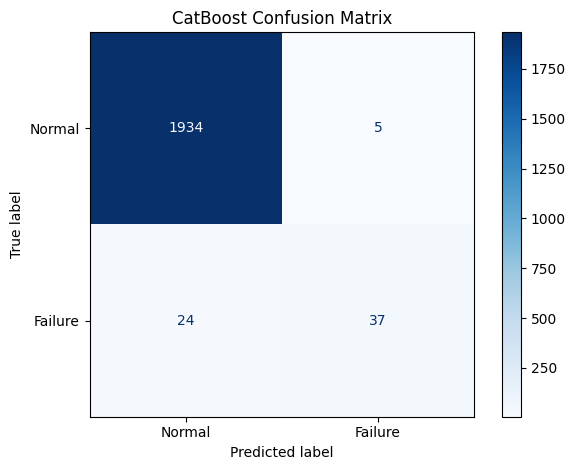

In [34]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predict using CatBoost
cat_pred = cat_model.predict(X_test).ravel()

# Evaluate model
print("CatBoost Accuracy:",
      accuracy_score(y_test, cat_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    cat_pred,
    target_names=["Normal", "Failure"],
    zero_division=0
))

# Plot confusion matrix
cm = confusion_matrix(y_test, cat_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Failure"]
).plot(cmap="Blues")

plt.title("CatBoost Confusion Matrix")
plt.tight_layout()
plt.show()

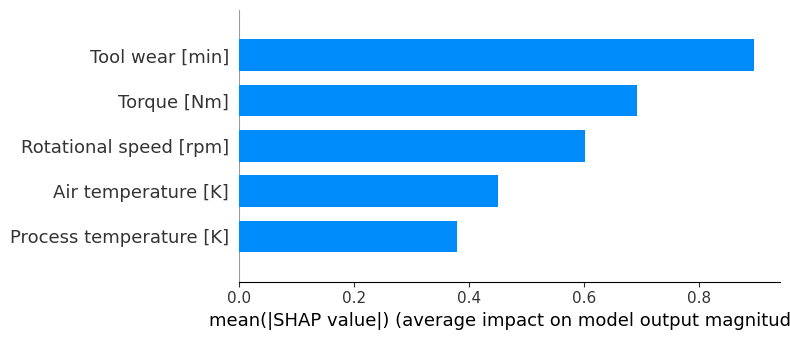

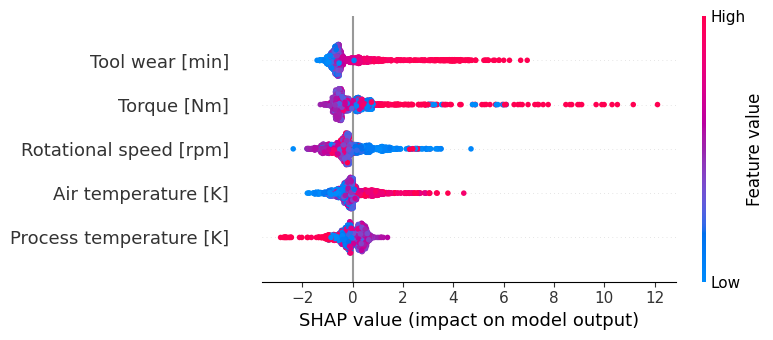

In [35]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Create SHAP explainer for CatBoost
explainer_cat = shap.TreeExplainer(cat_model)

# Calculate SHAP values
shap_values_cat = explainer_cat.shap_values(X_test)

# Select Failure-class SHAP values for binary classification
if isinstance(shap_values_cat, list):
    shap_failure = shap_values_cat[1]
elif np.asarray(shap_values_cat).ndim == 3:
    shap_failure = np.asarray(shap_values_cat)[:, :, 1]
else:
    shap_failure = shap_values_cat

# Overall feature importance
shap.summary_plot(
    shap_failure,
    X_test,
    plot_type="bar",
    show=True
)

# Detailed feature impact
shap.summary_plot(
    shap_failure,
    X_test,
    show=True
)

In [36]:
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

cat_model.save_model(
    str(model_dir / "predictive_maintenance_catboost.cbm")
)

print("Final CatBoost model saved successfully!")

Final CatBoost model saved successfully!


In [37]:
import json
from pathlib import Path

# Save the exact model input features
model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

feature_columns = list(cat_model.feature_names_)

with open(model_dir / "feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=4)

print("Features required by CatBoost:")
print(feature_columns)
print("\nFeature list saved successfully!")

Features required by CatBoost:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Feature list saved successfully!
